In [7]:
import json
import os
import pandas as pd
from datasets import load_dataset
from together import Together
import random
from dotenv import load_dotenv
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import time
import tqdm
import numpy as np
import nbformat

In [8]:
# temp variables until someone can run the file to get the variables loaded in 
llama_accuracy = 0.68
llama_precision = 1.00
llama_recall = 0.35
llama_f1 = 0.52

deepseek_accuracy = 0.83
deepseek_precision = 0.81
deepseek_recall = 0.88
deepseek_f1 = 0.84

grpo_accuracy = 0.74
grpo_precision = 0.96
grpo_recall = 0.52
grpo_f1 = 0.68

In [9]:
# try to run results .ipynb to overwrite the temporary results above
try:
    with open('results.ipynb') as f:
        nb = nbformat.read(f, as_version=4)

    exec('\n'.join(cell['source'] for cell in nb['cells'] if cell['cell_type'] == 'code'))

except Exception as e:
    print(f"Skipping operation due to authentication error: {e}")

Skipping operation due to authentication error: invalid syntax (<string>, line 201)


In [13]:
#create df of results to be used in graph
data = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1'],
    'LLaMA': [llama_accuracy, llama_precision, llama_recall, llama_f1],
    'GRPO': [grpo_accuracy, grpo_precision, grpo_recall, grpo_f1],
    'DeepSeek': [deepseek_accuracy, deepseek_precision, deepseek_recall, deepseek_f1]
})

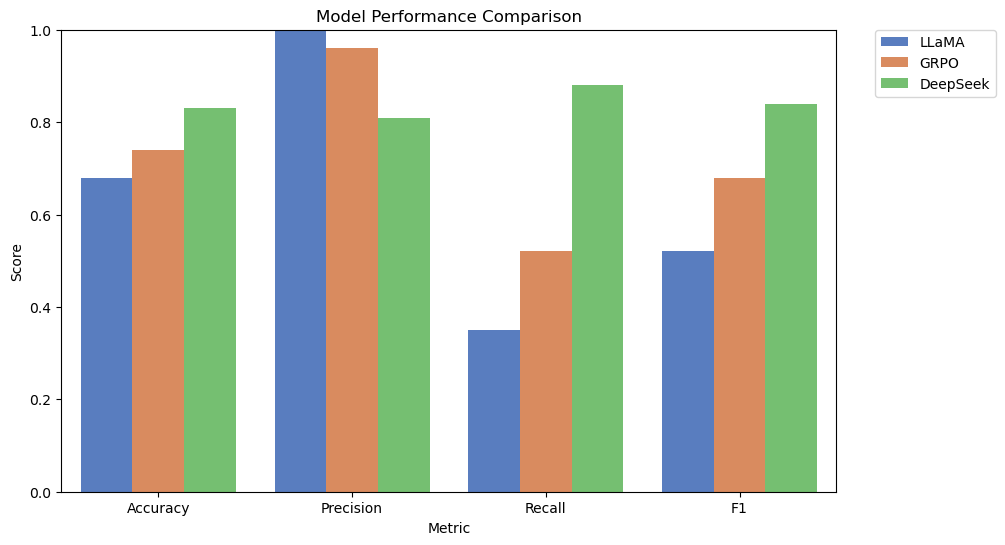

In [14]:
# create a box plot for all four results
df_long = data.melt(id_vars='Metric', var_name='Model', value_name='Score')

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Metric', y='Score', hue='Model', data=df_long, palette='muted')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)

# save fig as png
plt.savefig('images/boxplot.png', dpi=300, bbox_inches='tight')

plt.show()

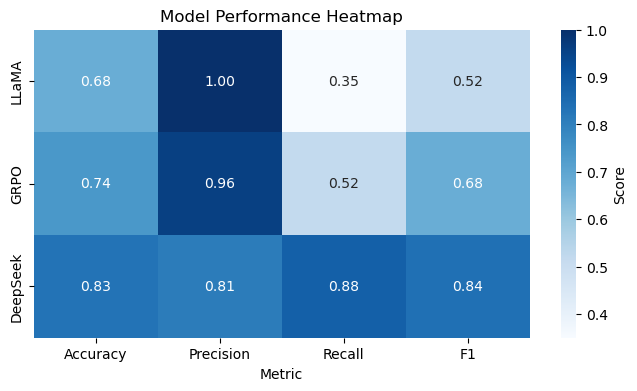

In [17]:
# create a heatmap for accuracy
llama_scores = [llama_accuracy, llama_precision, llama_recall, llama_f1]
deepseek_scores = [deepseek_accuracy, deepseek_precision, deepseek_recall, deepseek_f1]
grpo_scores = [grpo_accuracy, grpo_precision, grpo_recall, grpo_f1]
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']

# create DataFrame for heatmap
heatmap_data = pd.DataFrame({
    'Metric': metrics,
    'LLaMA': llama_scores,
    'GRPO': grpo_scores,
    'DeepSeek': deepseek_scores
}).set_index('Metric')

# heatmap
plt.figure(figsize=(8, 4))
sns.heatmap(heatmap_data.T, annot=True, cmap='Blues', cbar_kws={'label': 'Score'}, fmt=".2f")
plt.title('Model Performance Heatmap')

# save fig as png
plt.savefig('images/heatmap.png', dpi=300, bbox_inches='tight')

plt.show()

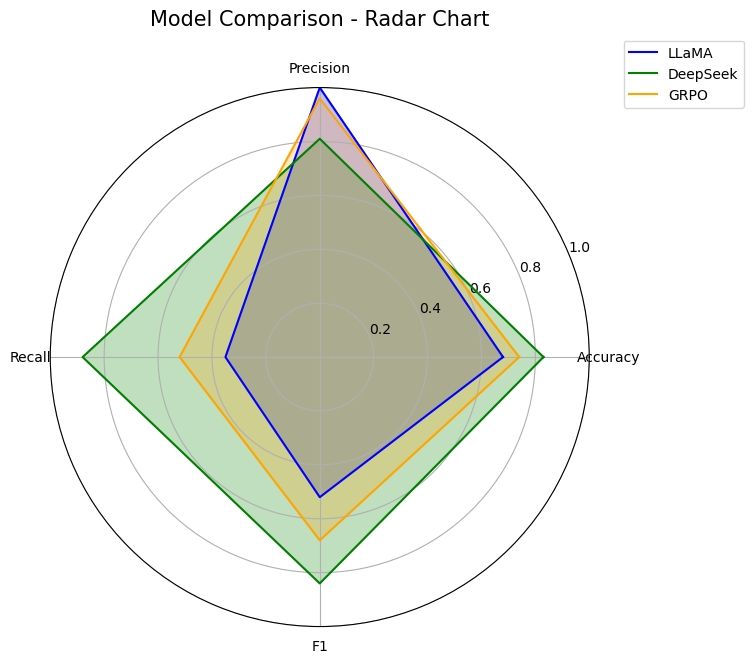

In [20]:
# radar chart of results

def make_radar_chart(metrics, scores, label, color, ax):
    
    # create circle
    angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
    scores = scores + [scores[0]]
    angles += angles[:1]
    
    # set up labels
    ax.plot(angles, scores, label=label, color=color)
    ax.fill(angles, scores, color=color, alpha=0.25)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics)

# set up polar plot
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

# create radar chart for each
make_radar_chart(metrics, llama_scores, 'LLaMA', 'blue', ax)
make_radar_chart(metrics, deepseek_scores, 'DeepSeek', 'green', ax)
make_radar_chart(metrics, grpo_scores, 'GRPO', 'orange', ax)

ax.set_ylim(0, 1)

plt.title('Model Comparison - Radar Chart', size=15, y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

# save fig as png
plt.savefig('images/radarchart', dpi=300, bbox_inches='tight')

plt.show()